# Bottom tracers around Antarctica

We take CFC-11, SF$_6$, and $\sigma_2$ in the deepest wet cell of each column around Antarctica and average them over the periods shown in Figures 7–9, for both experiments. Inputs are the yearly CM4X tracers on depth levels.

In [1]:
import sys

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr

sys.path.insert(0, "../src")
from paths import outputdir
from cm4x import open_cm4x_tracers
from plotting import set_style, plot_antarctic

set_style(dpi=150)

bottom_vars = ["cfc11", "sf6", "sigma2_offline"]
periods = [(1900, 1920), (1960, 1980), (1980, 2000), (2000, 2020), (2020, 2040)]  # inclusive year ranges

In [2]:
from dask.distributed import Client
from dask_jobqueue import SLURMCluster

# ~30 GB of 3-D tracers (one year per chunk); a few nodes are plenty
cluster = SLURMCluster(cores=36, processes=1, memory="190GB", walltime="01:00:00",
                       queue="scavenger", log_directory="logs")
cluster.scale(jobs=1)
client = Client(cluster)
client.wait_for_workers(1)
client

/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33053 instead
  warnings.warn(


<Client: 'tcp://10.151.1.98:36121' processes=0 threads=0, memory=0 B>

In [3]:
ds = open_cm4x_tracers(parallel=False)[bottom_vars]  # SLURM workers cannot import cm4x
ds

<xarray.Dataset> Size: 30GB
Dimensions:         (expt: 2, year: 250, z_l: 35, yh: 150, xh: 720)
Coordinates:
  * expt            (expt) object 16B 'control' 'forced'
  * year            (year) int64 2kB 1850 1851 1852 1853 ... 2096 2097 2098 2099
  * z_l             (z_l) float64 280B 2.5 10.0 20.0 ... 5.5e+03 6e+03 6.5e+03
  * yh              (yh) int64 1kB 0 1 2 3 4 5 6 ... 143 144 145 146 147 148 149
  * xh              (xh) int64 6kB 0 1 2 3 4 5 6 ... 713 714 715 716 717 718 719
    areacello       (yh, xh) float64 864kB 1.057e+08 1.056e+08 ... 1.144e+09
    deptho          (yh, xh) float32 432kB nan nan nan ... 5.106e+03 4.753e+03
    geolat          (yh, xh) float64 864kB -82.4 -82.4 -82.39 ... -52.52 -52.52
    geolon          (yh, xh) float64 864kB -298.5 -298.0 -297.5 ... 59.25 59.75
    lat             (yh, xh) float64 864kB -82.4 -82.4 -82.39 ... -52.52 -52.52
    lon             (yh, xh) float64 864kB -298.5 -298.0 -297.5 ... 59.25 59.75
    wet             (yh, xh) float32 432kB 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 1.0
Data variables:
    cfc11           (expt, year, z_l, yh, xh) float32 8GB dask.array<chunksize=(1, 1, 35, 150, 720), meta=np.ndarray>
    sf6             (expt, year, z_l, yh, xh) float32 8GB dask.array<chunksize=(1, 1, 35, 150, 720), meta=np.ndarray>
    sigma2_offline  (expt, year, z_l, yh, xh) float64 15GB dask.array<chunksize=(1, 1, 35, 150, 720), meta=np.ndarray>
Attributes:
    filename:            ocean_inert_z.044601-045012.cfc11.nc
    title:               CM4_piControl_c192_OM4p125_v8
    associated_files:    areacello: 04460101.ocean_static.nc
    grid_type:           regular
    grid_tile:           N/A
    external_variables:  volcello areacello
    provenance:          Diagnostics have been conservatively coarsened by He...

## Period means of the bottom values

In [4]:
# average each period first, then take the deepest wet cell (fixed in time on z-levels)
period_mean = xr.concat(
    [ds.sel(year=slice(start, end)).mean("year") for start, end in periods],
    dim=xr.IndexVariable("period", [f"{start}-{end}" for start, end in periods]),
)
bottom = period_mean.ffill("z_l").isel(z_l=-1)
bottom = bottom.assign_coords(
    start_year=("period", [p[0] for p in periods]),
    end_year=("period", [p[1] for p in periods]),
).drop_vars(["z_l", "z_i"], errors="ignore")

In [5]:
bottom.to_zarr(outputdir("Southern_Ocean_bottom_tracers_periods.zarr"), mode="w")
client.close()
cluster.close()

/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## Check: bottom fields in the control run, 2000–2020

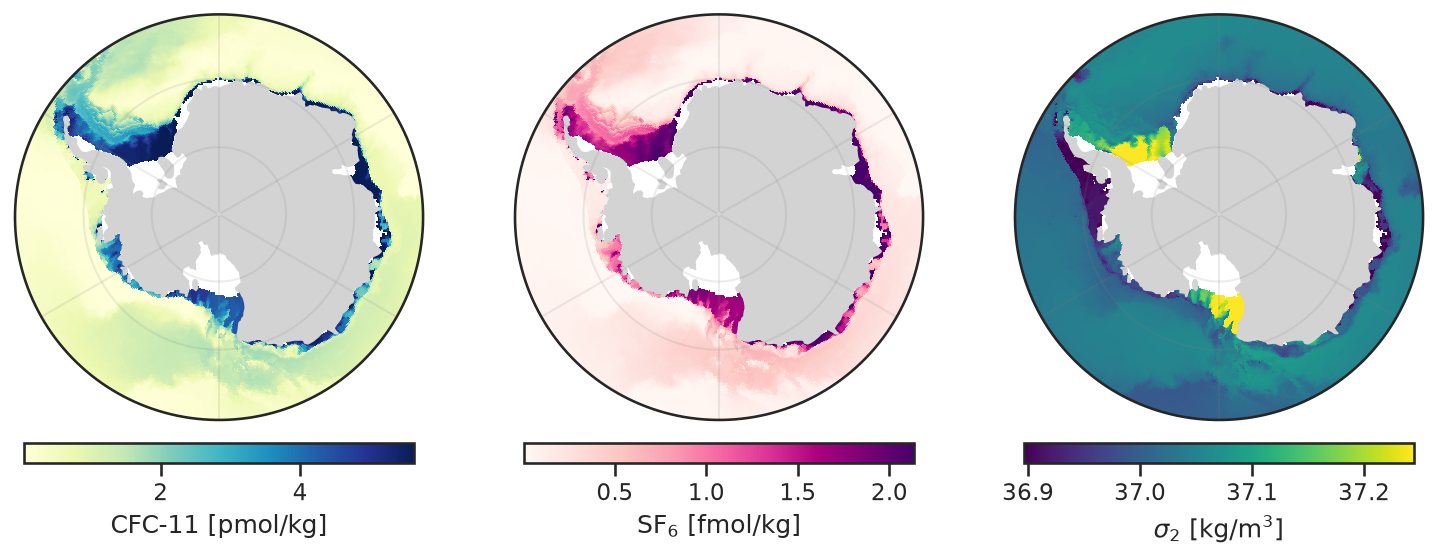

In [6]:
bottom = xr.open_dataset(outputdir("Southern_Ocean_bottom_tracers_periods.zarr"), engine="zarr")
control = bottom.sel(expt="control", period="2000-2020")

fields = [
    (1e12 / 1035 * control["cfc11"], "CFC-11 [pmol/kg]", "YlGnBu"),  # mol m-3 -> pmol kg-1
    (1e15 / 1035 * control["sf6"], r"SF$_6$ [fmol/kg]", "RdPu"),  # mol m-3 -> fmol kg-1
    (control["sigma2_offline"], r"$\sigma_2$ [kg/m$^3$]", "viridis"),
]
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6), subplot_kw={"projection": ccrs.SouthPolarStereo()},
                         constrained_layout=True)
for ax, (da, label, cmap) in zip(axes, fields):
    vmin, vmax = da.quantile([0.02, 0.98]).values
    mesh = plot_antarctic(da, ax, mask_threshold=None, draw_labels=False,
                          plot_kwargs=dict(cmap=cmap, vmin=vmin, vmax=vmax))
    fig.colorbar(mesh, ax=ax, orientation="horizontal", shrink=0.8, label=label)